In [ ]:
# Time to plot.
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    # Use LaTeX for all text rendering
    "text.usetex": True,

    # Match LaTeX default font
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],

    # Font sizes (11pt article standard)
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,

    # Figure layout
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "figure.autolayout": False,

    # Lines and markers
    "lines.linewidth": 1.5,
    "lines.markersize": 5,

    # Axes styling
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
})

FIGSIZE_SINGLE = (3.4, 2.5)   # inches
FIGSIZE_DOUBLE = (6.8, 3.5)
FIGSIZE_MEDIUM = (1.3 * FIGSIZE_SINGLE[0], 1.3 * FIGSIZE_SINGLE[1])
FIGSIZE_SINGLE_SQUARE = (3.4, 3.4)
FIGSIZE_MEDIUM_SQUARE = (3.4 * 1.3, 3.4 * 1.3)
FIGSIZE_PP = (6.8, 6.8/2.3567)

from cycler import cycler
cmap = plt.get_cmap("tab10")
colors = cmap(np.linspace(0, 1, 10))

mpl.rcParams['axes.prop_cycle'] = cycler(color=colors)
COL = plt.rcParams['axes.prop_cycle'].by_key()['color']

## Illustrate data augmentation

In [5]:
import torch
from torchvision import datasets, transforms
from PIL import Image

In [2]:
def transform(image, horizontal_flip, color_jitter, rotation):
    image_size=224
    train_transform = transforms.Compose([
            transforms.RandomCrop(image_size),
            # transforms.RandomResizedCrop(
            #     image_size,
            #     scale=(0.7, 1.0),
            #     ratio=(0.75, 1.33)
            # ) if random_crop else None,#transforms.Resize((image_size, image_size)),
            transforms.RandomHorizontalFlip() if horizontal_flip else None,
            transforms.ColorJitter(
                brightness=0.2,
                contrast=0.2,
                saturation=0.2,
                hue=0.05
            ) if color_jitter else None,
            transforms.RandomRotation(5) if rotation else None])
    return train_transform(image)

In [6]:
for i in range(5):
    img = Image.open("albania_image_downscaled.jpg")
    augmented_img = transform(img, horizontal_flip=True, color_jitter=True, rotation=True)
    augmented_img.save(f"augmented_example_images/albania_augmented_{i}.jpg")

## Test for duplicates

In [7]:
import hashlib
import os

In [ ]:
def find_and_delete_duplicates(directory, extensions=None, delete=False):
    if extensions is None:
        extensions = [".jpg", ".jpeg", ".png"]

    def file_hash(filepath):
        hasher = hashlib.md5()
        with open(filepath, "rb") as f:
            for chunk in iter(lambda: f.read(4096), b""):
                hasher.update(chunk)
        return hasher.hexdigest()

    hashes = {}
    duplicates = []

    for root, _, files in os.walk(directory):
        files.sort()
        for file in files:
            if any(file.lower().endswith(ext) for ext in extensions):
                filepath = os.path.join(root, file)
                try:
                    hash_value = file_hash(filepath)
                    if hash_value in hashes:
                        duplicates.append(filepath)
                        
                        if delete:
                            os.remove(filepath)
                            print(f"Deleted duplicate: {filepath}")
                        else:
                            print(f"Found duplicate: {filepath}")
                            #print(hash_value)
                            #print(hashes[hash_value])
                    else:
                        hashes[hash_value] = filepath
                except Exception as e:
                    print(f"Error processing file {filepath}: {e}")

    return duplicates

In [22]:
dir = "/Users/august/Desktop/AppliedMLdata2026"
d = find_and_delete_duplicates(dir, delete=False)

In [21]:
print(len(d))

348


In [25]:
# Print all folder names in directory
dir = "/Users/august/Desktop/AppliedMLdata2026/train_data"
countries = []
for root, dirs, files in os.walk(dir):
    for d in dirs:
        countries.append(d)

# sort alphabetically
countries.sort()
print(countries)

['Albania', 'Argentina', 'Australia', 'Austria', 'Bangladesh', 'Belgium', 'Bhutan', 'Bolivia', 'Botswana', 'Brazil', 'Bulgaria', 'Cambodia', 'Canada', 'Chile', 'Colombia', 'Croatia', 'Denmark', 'DominicanRepublic', 'Ecuador', 'Estonia', 'Eswatini', 'Finland', 'France', 'Germany', 'Ghana', 'Greece', 'Guatemala', 'Hungary', 'Iceland', 'India', 'Indonesia', 'Ireland', 'Israel', 'Italy', 'Japan', 'Jordan', 'Kazakhstan', 'Kenya', 'Kyrgyzstan', 'Laos', 'Latvia', 'Lebanon', 'Lesotho', 'Lithuania', 'Luxembourg', 'Madagascar', 'Malaysia', 'Malta', 'Mexico', 'Mongolia', 'Montenegro', 'Netherlands', 'NewZealand', 'Nigeria', 'NorthMacedonia', 'Norway', 'Oman', 'Panama', 'Peru', 'Philippines', 'Poland', 'Portugal', 'Qatar', 'Romania', 'Russia', 'Rwanda', 'Senegal', 'Serbia', 'Singapore', 'Slovakia', 'Slovenia', 'SouthAfrica', 'SouthKorea', 'Spain', 'Sweden', 'Switzerland', 'Thailand', 'Tunisia', 'Turkey', 'USA', 'Uganda', 'Ukraine', 'UnitedArabEmirates', 'UnitedKingdom', 'Uruguay']


In [41]:
import pandas as pd
# select column 1
class_names = pd.read_csv("../country_to_idx.csv", header=None).iloc[:, 0].tolist()

print(class_names)

['Albania', 'Argentina', 'Australia', 'Austria', 'Bangladesh', 'Belgium', 'Bhutan', 'Bolivia', 'Botswana', 'Brazil', 'Bulgaria', 'Cambodia', 'Canada', 'Chile', 'Colombia', 'Croatia', 'Denmark', 'DominicanRepublic', 'Ecuador', 'Estonia', 'Eswatini', 'Finland', 'France', 'Germany', 'Ghana', 'Greece', 'Guatemala', 'Hungary', 'Iceland', 'India', 'Indonesia', 'Ireland', 'Israel', 'Italy', 'Japan', 'Jordan', 'Kazakhstan', 'Kenya', 'Kyrgyzstan', 'Laos', 'Latvia', 'Lebanon', 'Lesotho', 'Lithuania', 'Luxembourg', 'Madagascar', 'Malaysia', 'Malta', 'Mexico', 'Mongolia', 'Montenegro', 'Netherlands', 'NewZealand', 'Nigeria', 'NorthMacedonia', 'Norway', 'Oman', 'Panama', 'Peru', 'Philippines', 'Poland', 'Portugal', 'Qatar', 'Romania', 'Russia', 'Rwanda', 'Senegal', 'Serbia', 'Singapore', 'Slovakia', 'Slovenia', 'SouthAfrica', 'SouthKorea', 'Spain', 'Sweden', 'Switzerland', 'Thailand', 'Tunisia', 'Turkey', 'USA', 'Uganda', 'Ukraine', 'UnitedArabEmirates', 'UnitedKingdom', 'Uruguay']


# Vis overtraining

In [4]:
import pandas as pd
history_50 = pd.read_csv("resnet50_classification_history.csv")
history_34 = pd.read_csv("resnet34_classification_history.csv")
history_18 = pd.read_csv("resnet18_classification_history.csv")

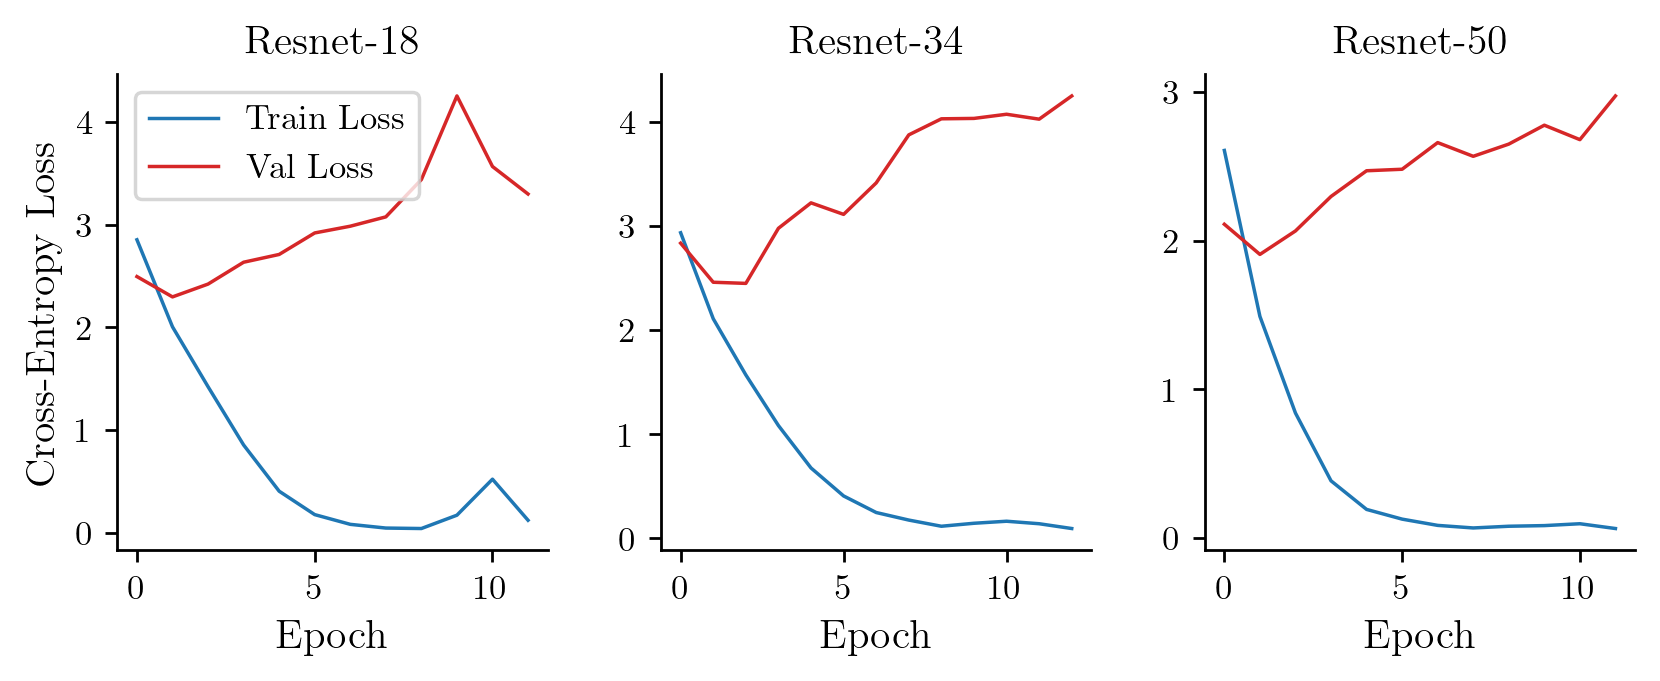

In [34]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1,3,figsize=(FIGSIZE_PP))
ax = ax.flatten()
c1 = COL[0]
c2 = COL[3]
lw = 1

ax[2].plot(history_50["train_loss"], label="Train Loss", color=c1, linewidth=lw)
ax[1].plot(history_34["train_loss"], label="Train Loss", color=c1, linewidth=lw)
ax[0].plot(history_18["train_loss"], label="Train Loss", color=c1, linewidth=lw)

ax[2].plot(history_50["val_loss"], label="Val Loss", color=c2, linewidth=lw)
ax[1].plot(history_34["val_loss"], label="Val Loss", color=c2, linewidth=lw)
ax[0].plot(history_18["val_loss"], label="Val Loss", color=c2, linewidth=lw)

ax[2].set_title("Resnet-50")
ax[1].set_title("Resnet-34")
ax[0].set_title("Resnet-18")
ax[0].set_xlabel("Epoch")
ax[1].set_xlabel("Epoch")
ax[2].set_xlabel("Epoch")
ax[0].set_ylabel("Cross-Entropy Loss")

ax[0].legend(loc="upper left") 

plt.tight_layout()
plt.savefig("training_history_plot.png", dpi=300)